In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set paths
dataset_folder = 'Dataset/'
normal_folder = 'Dataset/NormalClass/'

# Extract all zipped files from attacks
print("Extracting attack dataset files...")
for file in os.listdir(dataset_folder):
    if file.endswith('.zip') and 'NormalClass' not in file:
        zip_path = os.path.join(dataset_folder, file)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_folder)
        print(f"  ✓ Extracted {file}")

# Extract all zipped files from normal class
print("\nExtracting normal class dataset files...")
if os.path.exists(normal_folder):
    for file in os.listdir(normal_folder):
        if file.endswith('.zip'):
            zip_path = os.path.join(normal_folder, file)
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(normal_folder)
            print(f"Extracted {file}")



## 2. Load Datasets

In [2]:
# Load all attack CSVs
print("Loading attack datasets...")
dfs = []

for file in sorted(os.listdir(dataset_folder)):
    if file.endswith('.csv') and 'NormalClass' not in file:
        file_path = os.path.join(dataset_folder, file)
        try:
      
            attack_type = file.replace('.csv', '').replace('_attack', '').replace('DDoS_', 'DDoS_')
            
            df_temp = pd.read_csv(file_path)
            
         
            df_temp = df_temp.head(10000)
            if 'frame.time' in df_temp.columns:
                df_temp['frame.time'] = pd.to_datetime(df_temp['frame.time'], errors='coerce')
                df_temp = df_temp.dropna(subset=['frame.time'])
                
                # remove invalid years
                df_temp = df_temp[
                    (df_temp['frame.time'].dt.year >= 2000) &
                    (df_temp['frame.time'].dt.year <= 2030)
                ]

   
            df_temp = df_temp.head(10000)

          
            if 'Attack_type' not in df_temp.columns:
                df_temp['Attack_type'] = attack_type
            
            
            # Sort by IP and time
            if 'ip.src_host' in df_temp.columns and 'frame.time' in df_temp.columns:
                df_temp = df_temp.sort_values(['ip.src_host', 'frame.time']).reset_index(drop=True)
            
            dfs.append(df_temp)
            print(f"  ✓ {file:40s} - {len(df_temp):6d} rows")
        except Exception as e:
            print(f"  ✗ {file:40s} - Error: {str(e)}")


print("\nLoading normal class datasets...")
normal_folder = 'Dataset/NormalClass/'
if os.path.exists(normal_folder):
    normal_dfs = []
    for file in sorted(os.listdir(normal_folder)):
        if file.endswith('.csv'):
            file_path = os.path.join(normal_folder, file)
            try:
                df_temp = pd.read_csv(file_path)
                
                # Get a portion of normal data (enough to reach 10,000 total across all normal files)
                df_temp = df_temp.head(1000)  
                
                # Add attack type as 'Normal'
                df_temp['Attack_type'] = 'Normal'
                
                # Ensure frame.time is parsed as datetime
                if 'frame.time' in df_temp.columns:
                    df_temp['frame.time'] = pd.to_datetime(df_temp['frame.time'], errors='coerce')
                
                # Sort by IP and time
                if 'ip.src_host' in df_temp.columns and 'frame.time' in df_temp.columns:
                    df_temp = df_temp.sort_values(['ip.src_host', 'frame.time']).reset_index(drop=True)
                
                normal_dfs.append(df_temp)
                print(f"  ✓ {file:40s} - {len(df_temp):6d} rows")
            except Exception as e:
                print(f"  ✗ {file:40s} - Error: {str(e)}")
    
    if normal_dfs:
        df_normal = pd.concat(normal_dfs, axis=0, ignore_index=True).head(5000)
        dfs.append(df_normal)
        print(f"\n  ✓ Normal class combined - {len(df_normal):6d} rows (total from {len(normal_dfs)} files)")

print(f"\nCombining {len(dfs)} datasets into one sorted time series...")
df_combined = pd.concat(dfs, axis=0, ignore_index=True)

# Final sort by IP and time
if 'ip.src_host' in df_combined.columns and 'frame.time' in df_combined.columns:
    df_combined = df_combined.sort_values(['ip.src_host', 'frame.time']).reset_index(drop=True)

print(f"Combined dataset shape: {df_combined.shape}")
print(f"\nAttack types in dataset:")
print(df_combined['Attack_type'].value_counts())

Loading attack datasets...
  ✓ Backdoor_attack.csv                      -  10000 rows
  ✓ DDoS_HTTP_Flood_attack.csv               -  10000 rows
  ✓ DDoS_ICMP_Flood_attack.csv               -  10000 rows
  ✓ DDoS_TCP_SYN_Flood_attack.csv            -  10000 rows
  ✓ DDoS_UDP_Flood_attack.csv                -      0 rows
  ✓ MITM_attack.csv                          -      0 rows
  ✓ OS_Fingerprinting_attack.csv             -   1001 rows
  ✓ Password_attack.csv                      -  10000 rows
  ✓ Port_Scanning_attack.csv                 -  10000 rows
  ✓ Ransomware_attack.csv                    -  10000 rows
  ✓ SQL_injection_attack.csv                 -  10000 rows
  ✓ Uploading_attack.csv                     -  10000 rows
  ✓ Vulnerability_scanner_attack.csv         -  10000 rows
  ✓ XSS_attack.csv                           -  10000 rows

Loading normal class datasets...
  ✓ Distance.csv                             -   1000 rows
  ✓ Flame_Sensor.csv                         -   1000 

## 3. Data Preprocessing

In [3]:
# Remove duplicates
print(f"Removing duplicates...")
print(f"Before: {len(df_combined)} rows")
df_combined.drop_duplicates(subset=None, keep='first', inplace=True)
print(f"After: {len(df_combined)} rows")

# Drop columns with fixed values and problematic columns
drop_columns = [
    'ip.dst_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4',
    'http.file_data', 'http.request.full_uri', 'icmp.transmit_timestamp',
    'http.request.uri.query', 'tcp.options', 'tcp.payload', 'udp.port', 'mqtt.msg', 'http.referer', 'http.request.version', 'tcp.dstport', 'dns.qry.name', 'mqtt.topic', 'mqtt.protoname',
]

drop_columns = [col for col in drop_columns if col in df_combined.columns]
df_combined.drop(columns=drop_columns, inplace=True)

print(f"Dropped columns: {len(drop_columns)}")

Removing duplicates...
Before: 116001 rows
After: 115920 rows
Dropped columns: 17


In [4]:
# Identify columns with single unique value
print("Removing columns with single unique value...")
single_value_cols = []
for col in df_combined.columns:
    if df_combined[col].nunique() == 1 and col not in ['Attack_type', 'Attack_label']:
        single_value_cols.append(col)

if single_value_cols:
    df_combined.drop(columns=single_value_cols, inplace=True)
    print(f"Dropped {len(single_value_cols)} single-value columns")
else:
    print("No single-value columns found")

Removing columns with single unique value...
Dropped 7 single-value columns


In [5]:
numeric_cols = [
    'icmp.checksum',
    'icmp.seq_le',
    'tcp.ack_raw',
    'tcp.checksum',
    'tcp.connection.fin',
    'tcp.flags',
    'tcp.len',
    'tcp.srcport',
    'mqtt.conack.flags',
    'mqtt.conflags',
    'mqtt.hdrflags'
]

# Convert to numeric (invalid → NaN)
df_combined[numeric_cols] = df_combined[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows where ANY of these columns is not numeric
df_combined = df_combined.dropna(subset=numeric_cols)

In [6]:
# Identify categorical and numerical columns
print("\nIdentifying column types...")
categorical_cols = df_combined.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_combined.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove columns that shouldn't be encoded
if 'frame.time' in categorical_cols:
    categorical_cols.remove('frame.time')
if 'ip.src_host' in categorical_cols:
    categorical_cols.remove('ip.src_host')
if 'Attack_type' in categorical_cols:
    categorical_cols.remove('Attack_type')
if 'Attack_label' in categorical_cols:
    categorical_cols.remove('Attack_label')

print(f"Categorical columns: {len(categorical_cols)}")
for col in categorical_cols[:5]:  # Show first 5
    print(f"  • {col}: {df_combined[col].nunique()} unique values")


Identifying column types...
Categorical columns: 2
  • arp.hw.size: 6 unique values
  • http.request.method: 2 unique values


In [7]:
# One-hot encode categorical columns
print("\nOne-hot encoding categorical columns...")
for col in categorical_cols:
    dummies = pd.get_dummies(df_combined[col], prefix=col)
    df_combined = pd.concat([df_combined, dummies], axis=1)
    df_combined.drop(col, axis=1, inplace=True)
    print(f"  ✓ Encoded: {col}")

print(f"\nTotal columns after encoding: {df_combined.shape[1]}")


One-hot encoding categorical columns...
  ✓ Encoded: arp.hw.size
  ✓ Encoded: http.request.method

Total columns after encoding: 45


In [8]:
# Sort by source IP and time (for time series)
print("Sorting data by IP and time...")
df_combined['frame.time'] = pd.to_datetime(df_combined['frame.time'], errors='coerce')
df_combined = df_combined.sort_values(['ip.src_host', 'frame.time']).reset_index(drop=True)

print(f"Dataset shape: {df_combined.shape}")
print(f"Date range: {df_combined['frame.time'].min()} to {df_combined['frame.time'].max()}")

Sorting data by IP and time...
Dataset shape: (4115, 45)
Date range: 2021-01-01 00:00:06.541715 to 2022-01-01 00:48:15.953530


In [9]:
# Define feature columns (exclude temporal and meta columns)
exclude_cols = ['frame.time', 'ip.src_host', 'Attack_type', 'Attack_label']
feature_cols = [col for col in df_combined.columns if col not in exclude_cols]

print(f"Feature columns for scaling: {len(feature_cols)}")
print(f"\nFirst 10 feature columns:")
for col in feature_cols[:10]:
    print(f"  • {col}")

Feature columns for scaling: 41

First 10 feature columns:
  • arp.opcode
  • icmp.checksum
  • icmp.seq_le
  • http.content_length
  • http.response
  • http.tls_port
  • tcp.ack
  • tcp.ack_raw
  • tcp.checksum
  • tcp.connection.fin


In [10]:
# Scale features using both StandardScaler and MinMaxScaler
print("Scaling features...\n")
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df_features = df_combined[feature_cols].astype('float32')

# ===== StandardScaler (Z-score normalization) =====
print("1. StandardScaler (Z-score normalization):")
scaler_standard = StandardScaler()
df_features_standard = scaler_standard.fit_transform(df_features)
print(f"   Mean: {df_features_standard.mean():.6f}, Std: {df_features_standard.std():.6f}")

# Create scaled dataframe - StandardScaler
df_scaled = pd.DataFrame(df_features_standard, columns=feature_cols)
df_scaled['ip.src_host'] = df_combined['ip.src_host'].values
df_scaled['frame.time'] = df_combined['frame.time'].values
df_scaled['Attack_type'] = df_combined['Attack_type'].values

# ===== MinMaxScaler (Normalization to [0,1]) =====
print("\n2. MinMaxScaler (Normalization to [0,1]):")
scaler_minmax = MinMaxScaler(feature_range=(0, 1))
df_features_minmax = scaler_minmax.fit_transform(df_features)
print(f"   Min: {df_features_minmax.min():.6f}, Max: {df_features_minmax.max():.6f}")

# Create scaled dataframe - MinMaxScaler
df_scaled_minmax = pd.DataFrame(df_features_minmax, columns=feature_cols)
df_scaled_minmax['ip.src_host'] = df_combined['ip.src_host'].values
df_scaled_minmax['frame.time'] = df_combined['frame.time'].values
df_scaled_minmax['Attack_type'] = df_combined['Attack_type'].values

# Using StandardScaler as default for LSTM (more suitable for neural networks)
print("\n✓ Using StandardScaler for LSTM training (better for neural networks)")
print(f"   StandardScaler dataset shape: {df_scaled.shape}")
print(f"   MinMaxScaler dataset shape: {df_scaled_minmax.shape}")

# Rename for clarity - scaler is StandardScaler (default for LSTM)
scaler = scaler_standard

Scaling features...

1. StandardScaler (Z-score normalization):
   Mean: 0.000000, Std: 0.584349

2. MinMaxScaler (Normalization to [0,1]):
   Min: 0.000000, Max: 1.000000

✓ Using StandardScaler for LSTM training (better for neural networks)
   StandardScaler dataset shape: (4115, 44)
   MinMaxScaler dataset shape: (4115, 44)


=== Scaling Methods Comparison ===



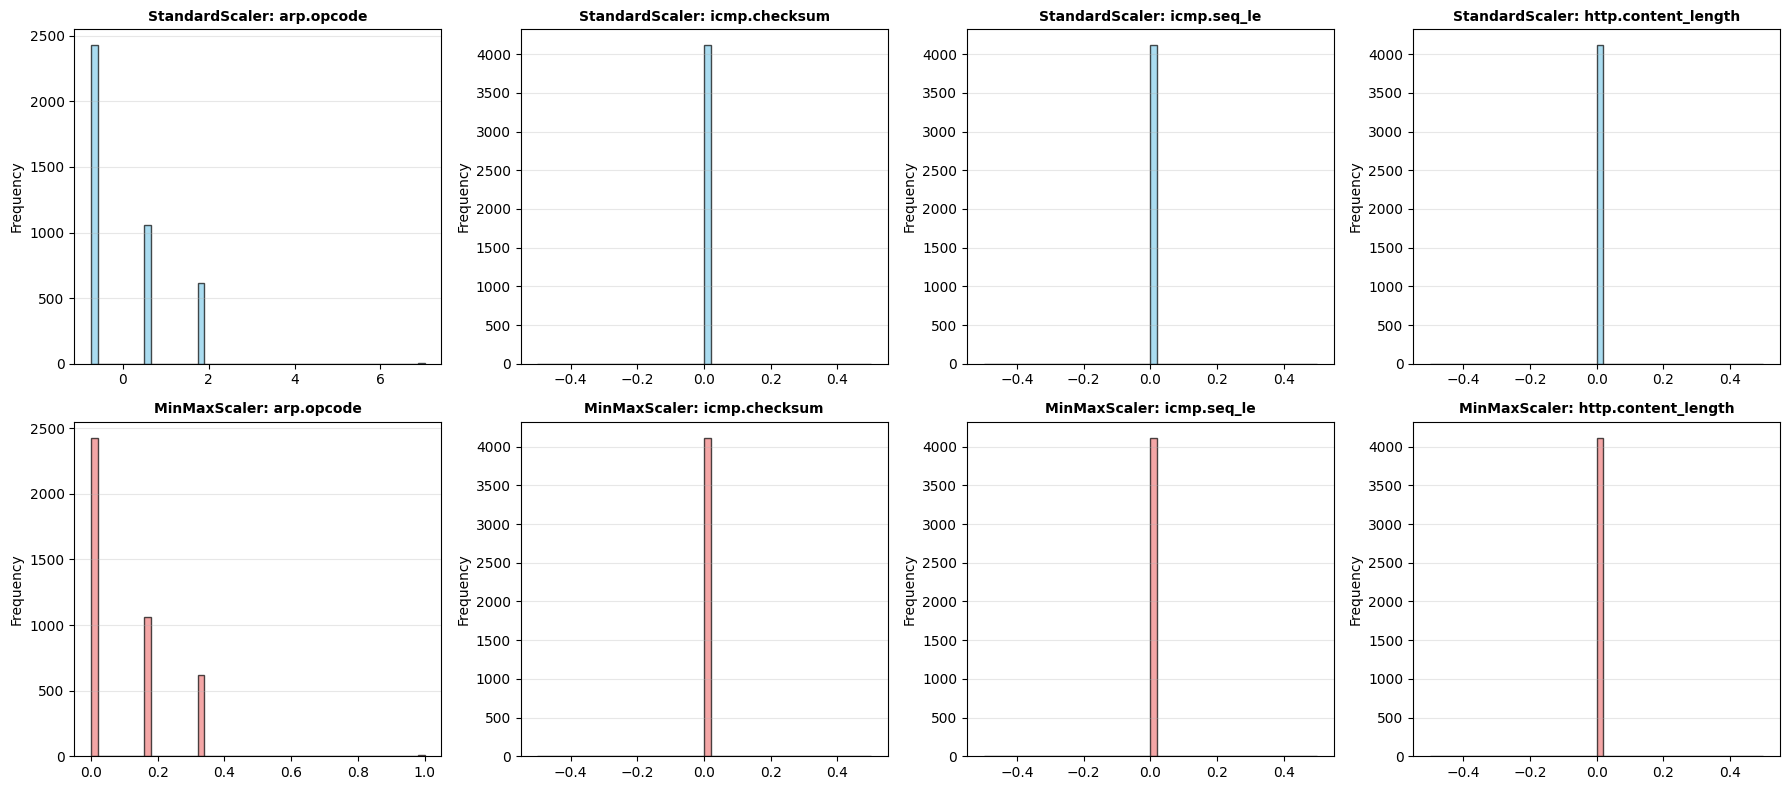

Feature Statistics Comparison:

StandardScaler (mean≈0, std≈1):
  Mean: -0.000000
  Std:  0.341505
  Min:  -2.581268
  Max:  45.348648

MinMaxScaler (range [0, 1]):
  Mean: 0.060824
  Std:  0.082072
  Min:  0.000000
  Max:  1.000000

📌 Note: StandardScaler is used for LSTM (default)
   To use MinMaxScaler, replace 'df_scaled' with 'df_scaled_minmax' in sequence creation


In [11]:
# Compare StandardScaler vs MinMaxScaler
print("=== Scaling Methods Comparison ===\n")

comparison_cols = feature_cols[:4]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, col in enumerate(comparison_cols):
    # StandardScaler distributions
    axes[0, idx].hist(df_scaled[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'StandardScaler: {col}', fontsize=10, fontweight='bold')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(axis='y', alpha=0.3)
    
    # MinMaxScaler distributions
    axes[1, idx].hist(df_scaled_minmax[col], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[1, idx].set_title(f'MinMaxScaler: {col}', fontsize=10, fontweight='bold')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics comparison
print("Feature Statistics Comparison:\n")
print("StandardScaler (mean≈0, std≈1):")
print(f"  Mean: {df_scaled[feature_cols].mean().mean():.6f}")
print(f"  Std:  {df_scaled[feature_cols].std().mean():.6f}")
print(f"  Min:  {df_scaled[feature_cols].min().min():.6f}")
print(f"  Max:  {df_scaled[feature_cols].max().max():.6f}")

print("\nMinMaxScaler (range [0, 1]):")
print(f"  Mean: {df_scaled_minmax[feature_cols].mean().mean():.6f}")
print(f"  Std:  {df_scaled_minmax[feature_cols].std().mean():.6f}")
print(f"  Min:  {df_scaled_minmax[feature_cols].min().min():.6f}")
print(f"  Max:  {df_scaled_minmax[feature_cols].max().max():.6f}")

print("\n📌 Note: StandardScaler is used for LSTM (default)")
print("   To use MinMaxScaler, replace 'df_scaled' with 'df_scaled_minmax' in sequence creation")

## Exploratory Data Analysis (EDA) 

=== Attack Type Distribution ===

Attack_type
Port_Scanning            1314
Ransomware               1137
Normal                    668
XSS                       477
Backdoor                  305
OS_Fingerprinting         150
Uploading                  23
Vulnerability_scanner      17
Password                   16
DDoS_TCP                    4
SQL_injection               4
Name: count, dtype: int64


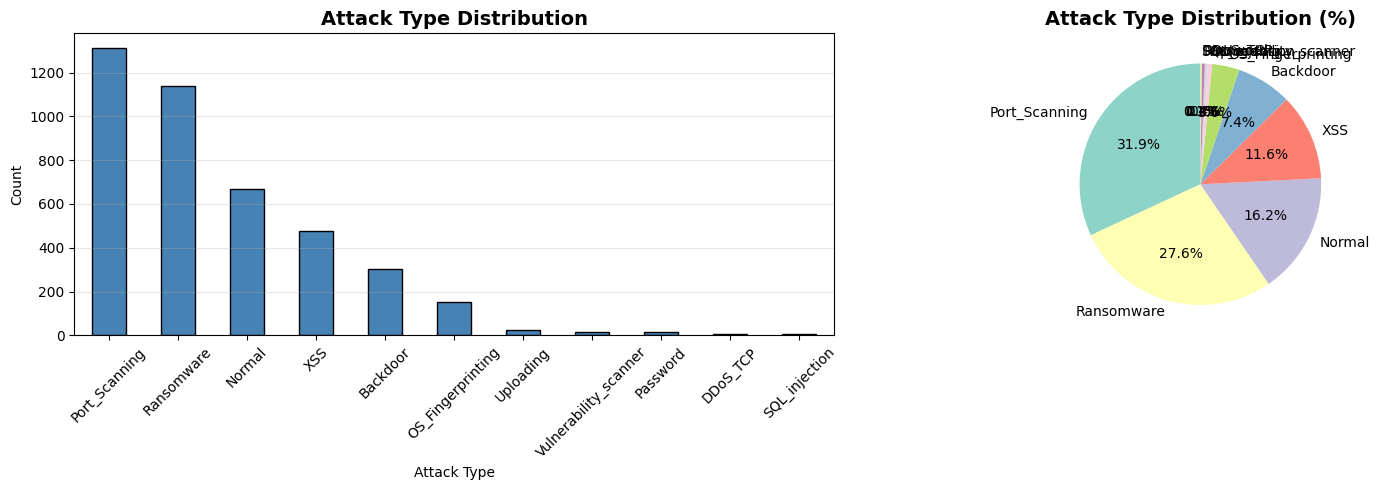


Total samples: 4115
Attack types: 11


In [12]:
# 1. Attack Type Distribution
print("=== Attack Type Distribution ===\n")
attack_counts = df_combined['Attack_type'].value_counts()
print(attack_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
attack_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Attack Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(attack_counts)))
axes[1].pie(attack_counts.values, labels=attack_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Attack Type Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal samples: {len(df_combined)}")
print(f"Attack types: {len(attack_counts)}")

=== Feature Statistics ===

Basic statistics of features:
                        count          mean       std       min       25%  \
arp.opcode             4115.0  4.449707e-08  1.000121 -0.736198 -0.736198   
icmp.checksum          4115.0  0.000000e+00  0.000000  0.000000  0.000000   
icmp.seq_le            4115.0  0.000000e+00  0.000000  0.000000  0.000000   
http.content_length    4115.0  0.000000e+00  0.000000  0.000000  0.000000   
http.response          4115.0  0.000000e+00  0.000000  0.000000  0.000000   
http.tls_port          4115.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.ack                4115.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.ack_raw            4115.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.checksum           4115.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.connection.fin     4115.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.connection.rst     4115.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.connection.syn

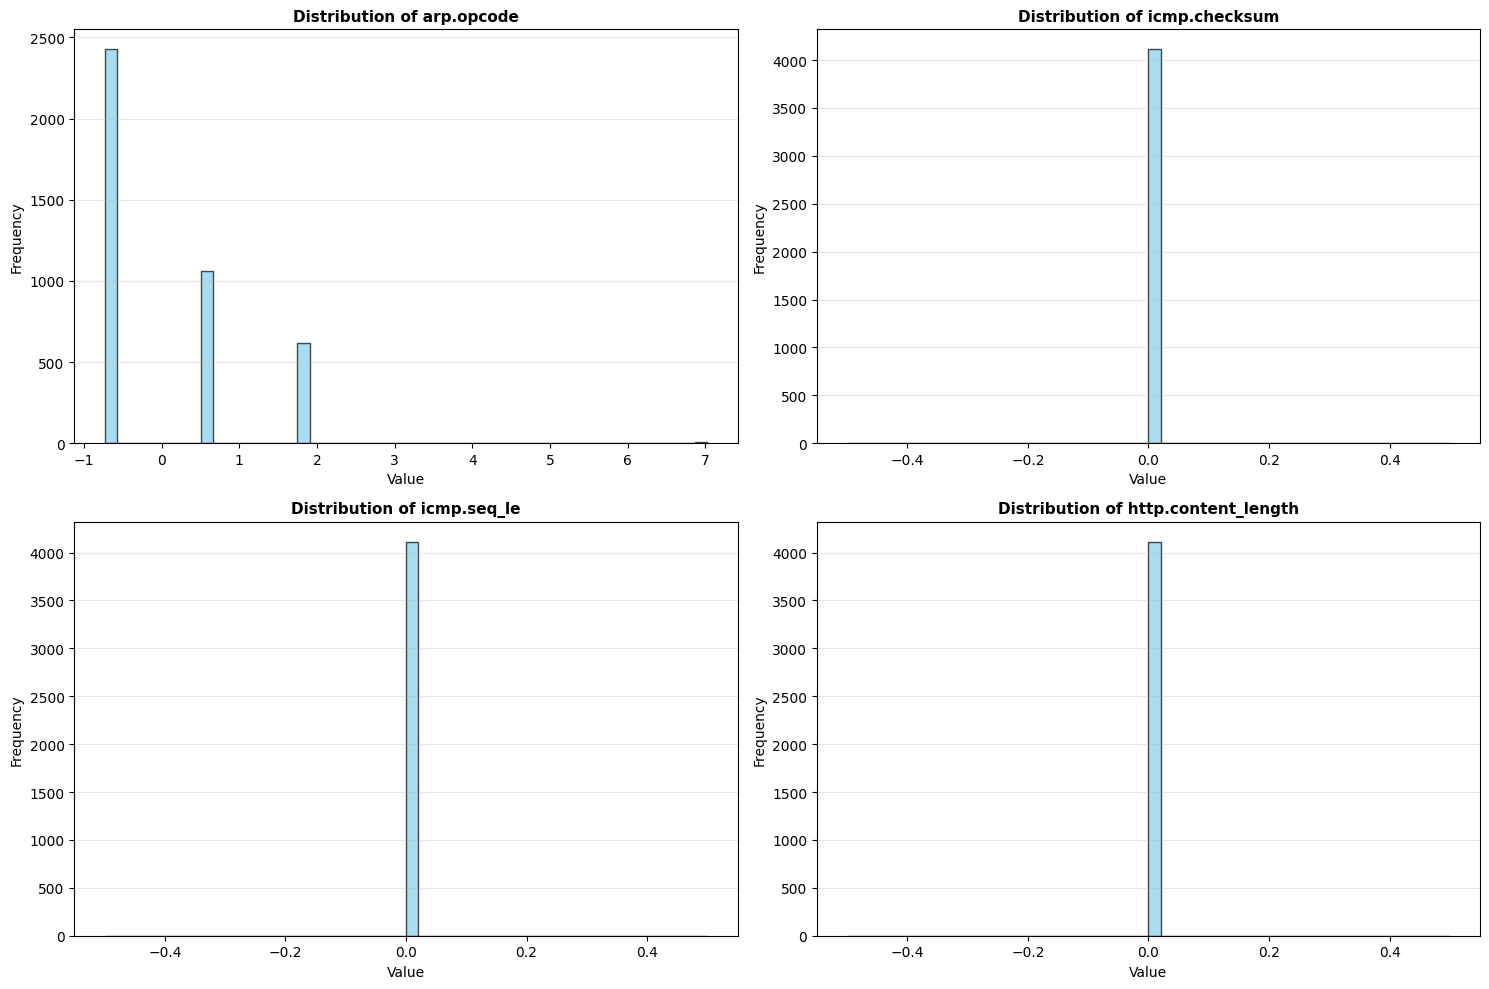


Total features (after encoding): 41


In [13]:
# 2. Feature Statistics
print("=== Feature Statistics ===\n")
print("Basic statistics of features:")
print(df_scaled[feature_cols].describe().T.head(15))  # Show first 15 features

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of first 4 features
for idx, col in enumerate(feature_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df_scaled[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal features (after encoding): {len(feature_cols)}")

=== Feature Correlation Analysis ===



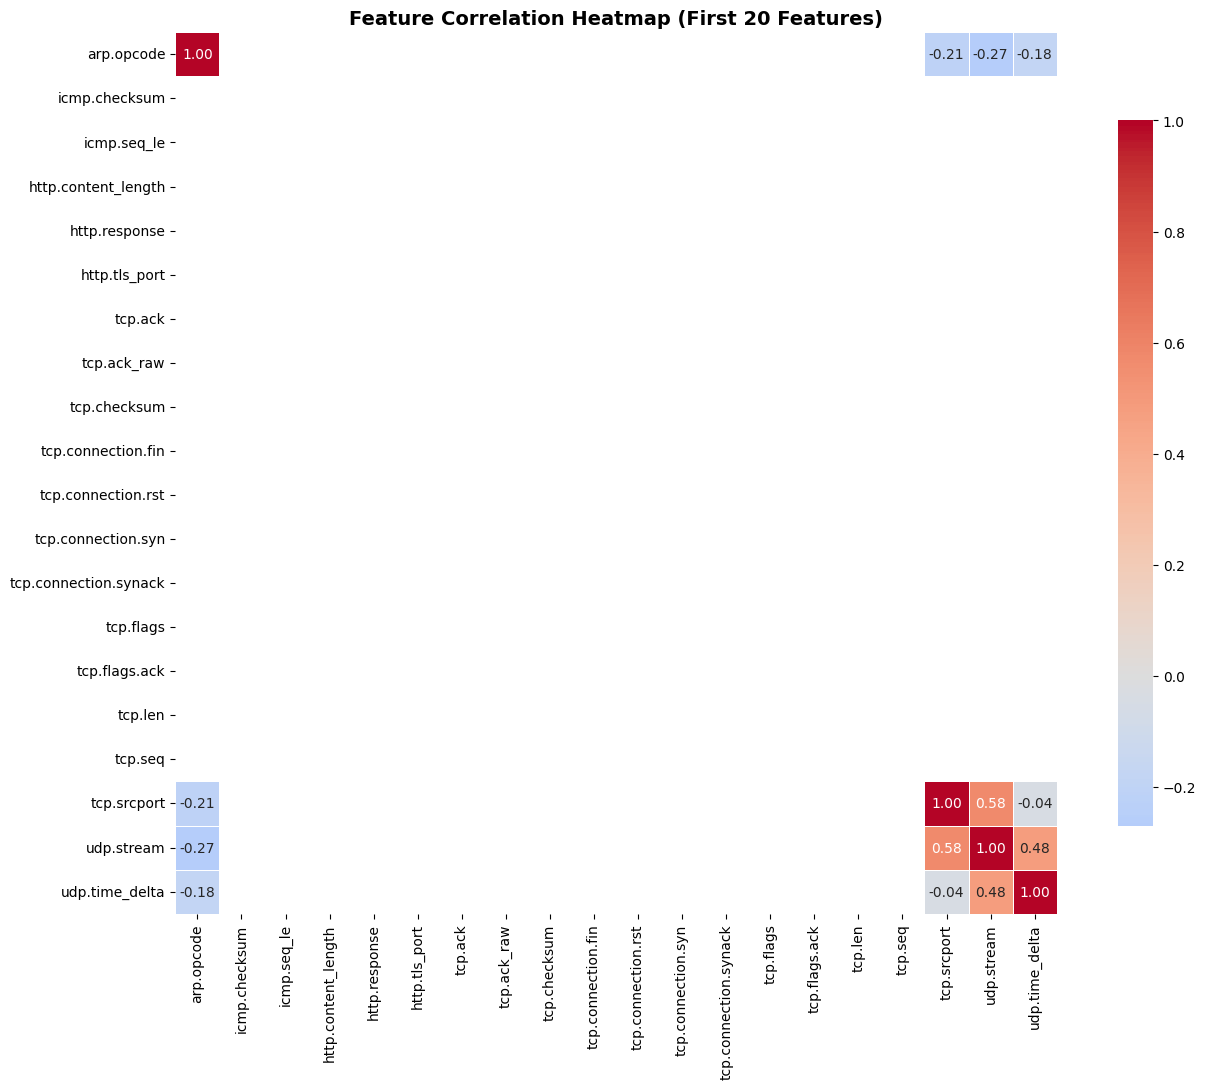

Top 10 feature correlations:
  1. arp.opcode <-> icmp.checksum: nan
  2. arp.opcode <-> icmp.seq_le: nan
  3. arp.opcode <-> http.content_length: nan
  4. arp.opcode <-> http.response: nan
  5. arp.opcode <-> http.tls_port: nan
  6. arp.opcode <-> tcp.ack: nan
  7. arp.opcode <-> tcp.ack_raw: nan
  8. arp.opcode <-> tcp.checksum: nan
  9. arp.opcode <-> tcp.connection.fin: nan
  10. arp.opcode <-> tcp.connection.rst: nan


In [14]:
# 3. Correlation Heatmap
print("=== Feature Correlation Analysis ===\n")

# Calculate correlation for first 20 features to avoid overcrowding
corr_cols = feature_cols[:20]
correlation_matrix = df_scaled[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap (First 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highest correlations
print("Top 10 feature correlations:")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], 
                          abs(correlation_matrix.iloc[i, j])))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
for i, (feat1, feat2, corr) in enumerate(corr_pairs[:10]):
    print(f"  {i+1}. {feat1} <-> {feat2}: {corr:.4f}")

=== Feature Distribution by Attack Type ===



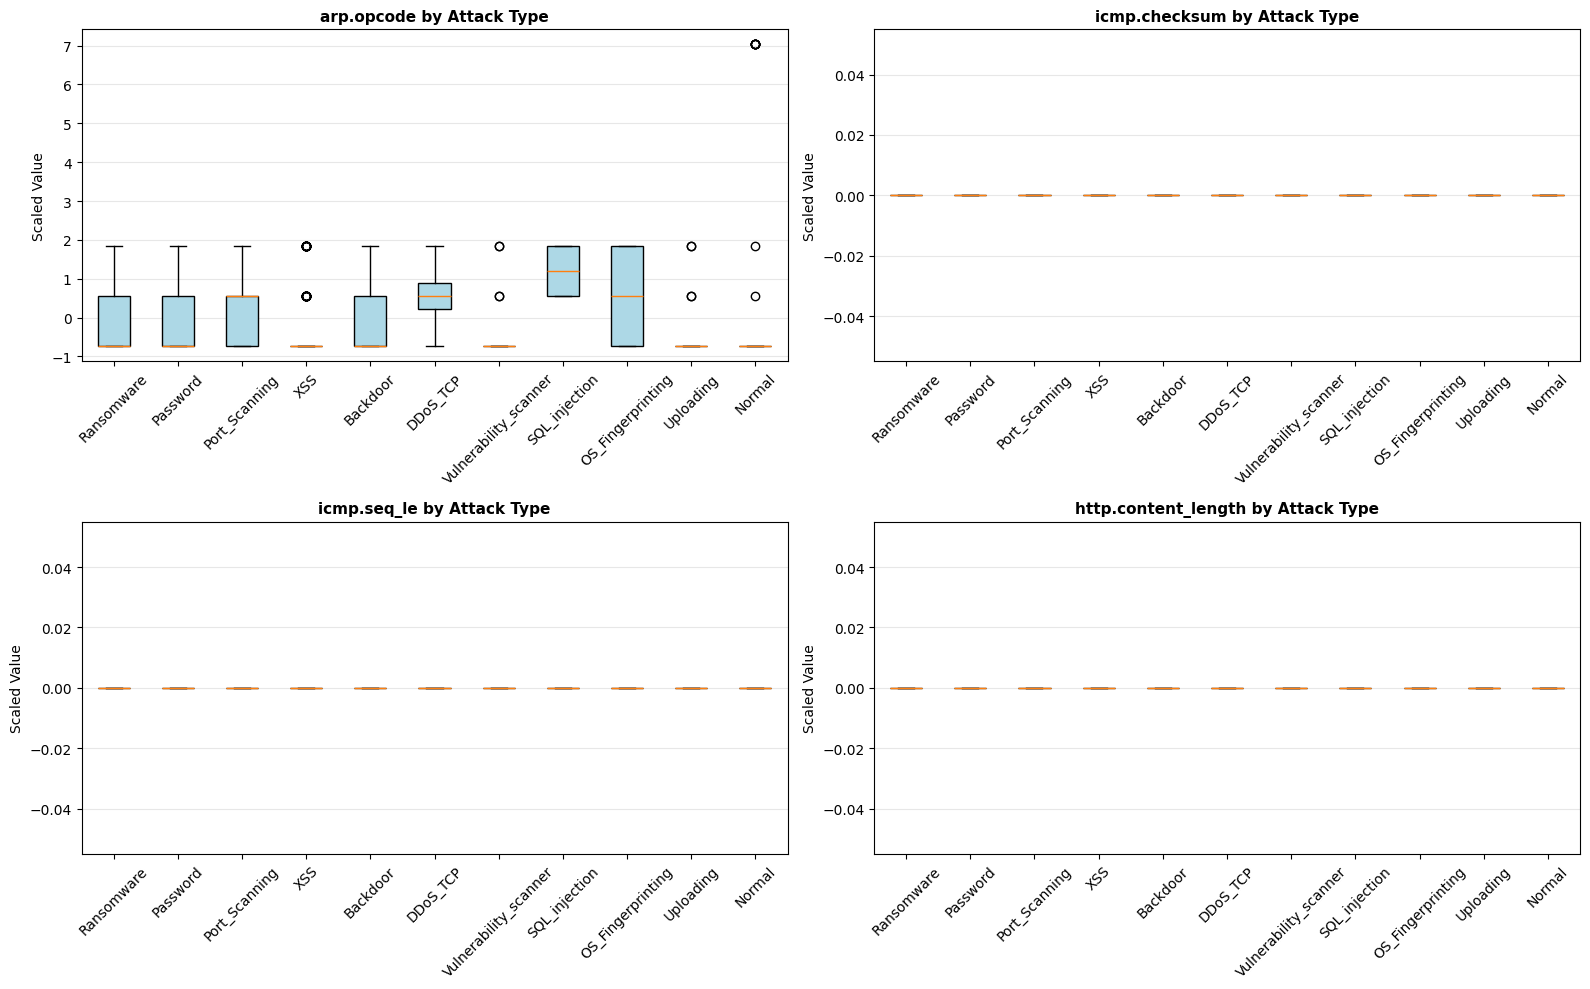

Box plots show feature distributions across different attack types


In [15]:
# 4. Attack Type Feature Comparison (Box plots)
print("=== Feature Distribution by Attack Type ===\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Select 4 features for comparison
compare_features = feature_cols[:4]

for idx, feature in enumerate(compare_features):
    ax = axes[idx // 2, idx % 2]
    
    # Create box plot for each attack type
    data_for_plot = [df_scaled[df_scaled['Attack_type'] == attack][feature].values 
                     for attack in df_combined['Attack_type'].unique()]
    
    bp = ax.boxplot(data_for_plot, labels=df_combined['Attack_type'].unique(), patch_artist=True)
    
    # Color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax.set_title(f'{feature} by Attack Type', fontsize=11, fontweight='bold')
    ax.set_ylabel('Scaled Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Box plots show feature distributions across different attack types")

=== Time Series Patterns ===



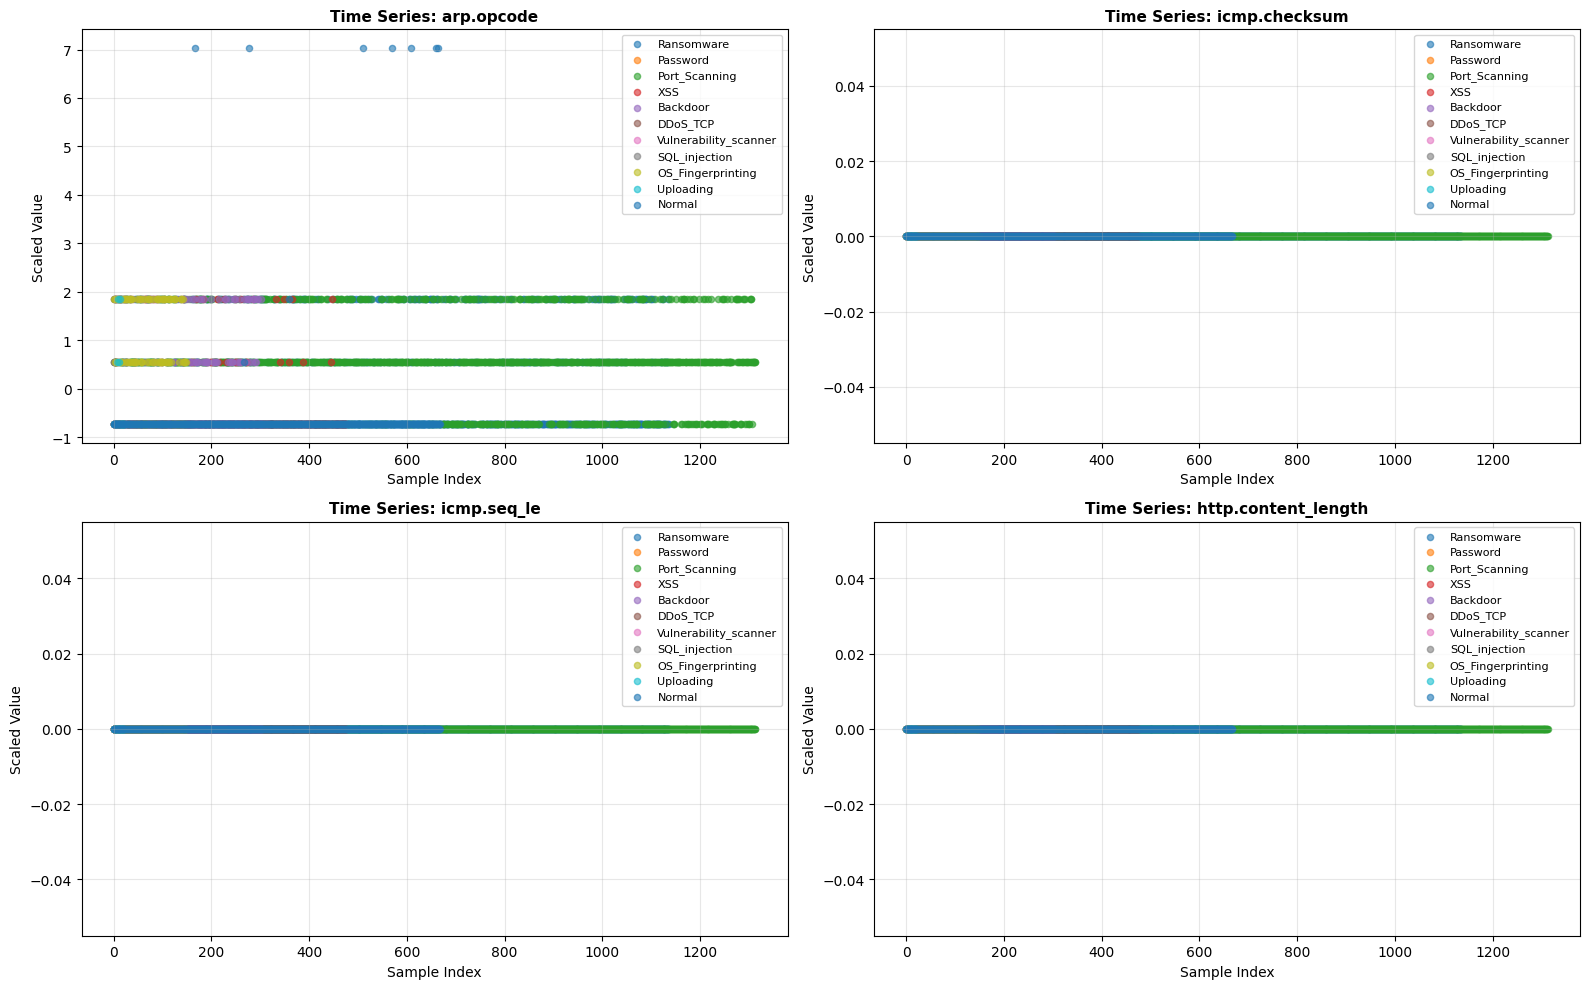

Time series patterns show how features vary across different attack types


In [16]:
# 5. Time Series Patterns - Feature values over time
print("=== Time Series Patterns ===\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot first feature values over time colored by attack type
for idx, feature in enumerate(feature_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    
    # Sample data for visualization (to avoid overcrowding)
    sample_df = df_scaled.sample(n=min(5000, len(df_scaled)), random_state=42)
    
    # Plot scatter for each attack type
    for attack_type in df_combined['Attack_type'].unique():
        attack_data = sample_df[sample_df['Attack_type'] == attack_type]
        ax.scatter(range(len(attack_data)), attack_data[feature], 
                  label=attack_type, alpha=0.6, s=20)
    
    ax.set_title(f'Time Series: {feature}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Scaled Value')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Time series patterns show how features vary across different attack types")

=== Mean Feature Values by Attack Type ===



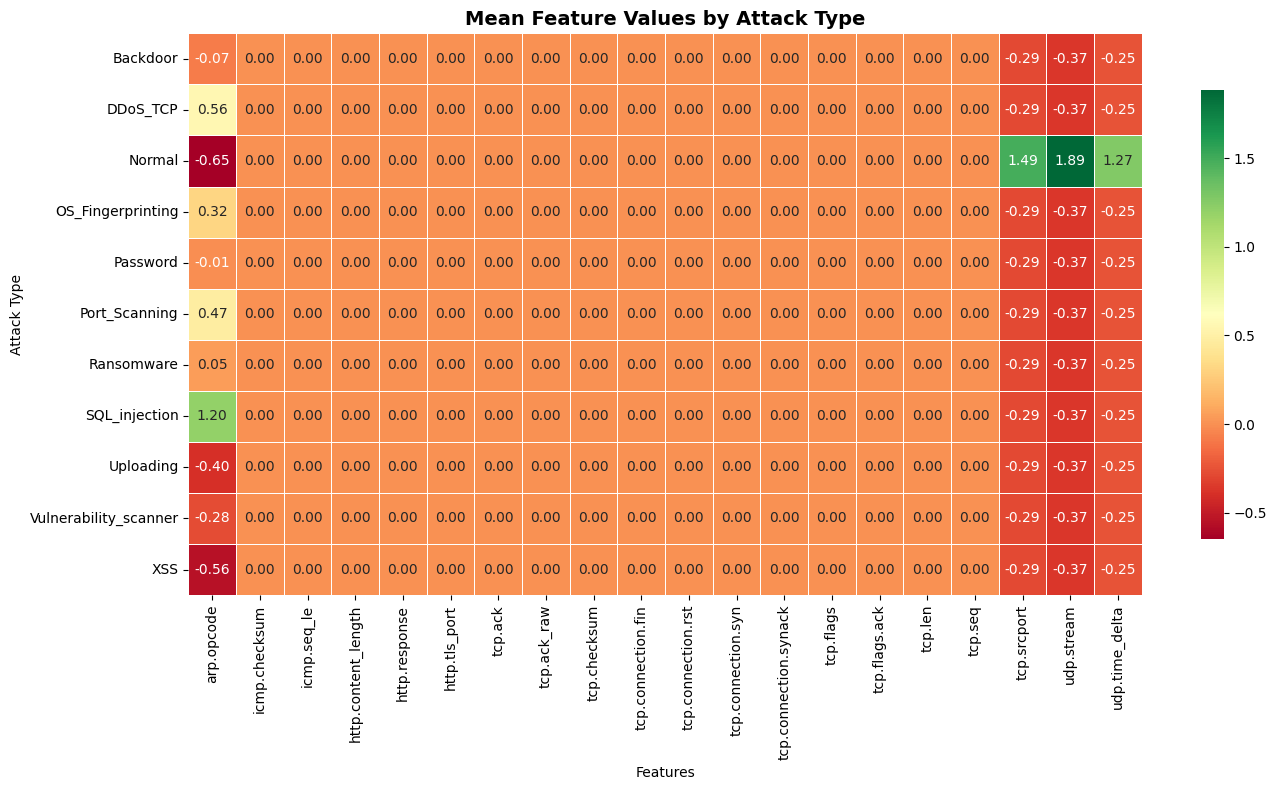


Mean values show characteristic patterns of each attack type


In [17]:
# 6. Attack Type Mean Features Heatmap
print("=== Mean Feature Values by Attack Type ===\n")

# Calculate mean features for each attack type (using first 20 features)
heatmap_features = feature_cols[:20]
mean_features = df_scaled.groupby('Attack_type')[heatmap_features].mean()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(mean_features, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={"shrink": 0.8}, linewidths=0.5, ax=ax)
ax.set_title('Mean Feature Values by Attack Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Attack Type')
plt.tight_layout()
plt.show()

print("\nMean values show characteristic patterns of each attack type")

=== Source IP Analysis ===

IP and Packet Statistics by Attack Type:
                       Unique_IPs  Total_Packets
Attack_type                                     
Backdoor                        3            305
DDoS_TCP                        1              4
Normal                          8              7
OS_Fingerprinting               3            150
Password                        3             16
Port_Scanning                   3           1314
Ransomware                      3           1137
SQL_injection                   1              4
Uploading                       3             23
Vulnerability_scanner           3             17
XSS                             3            477


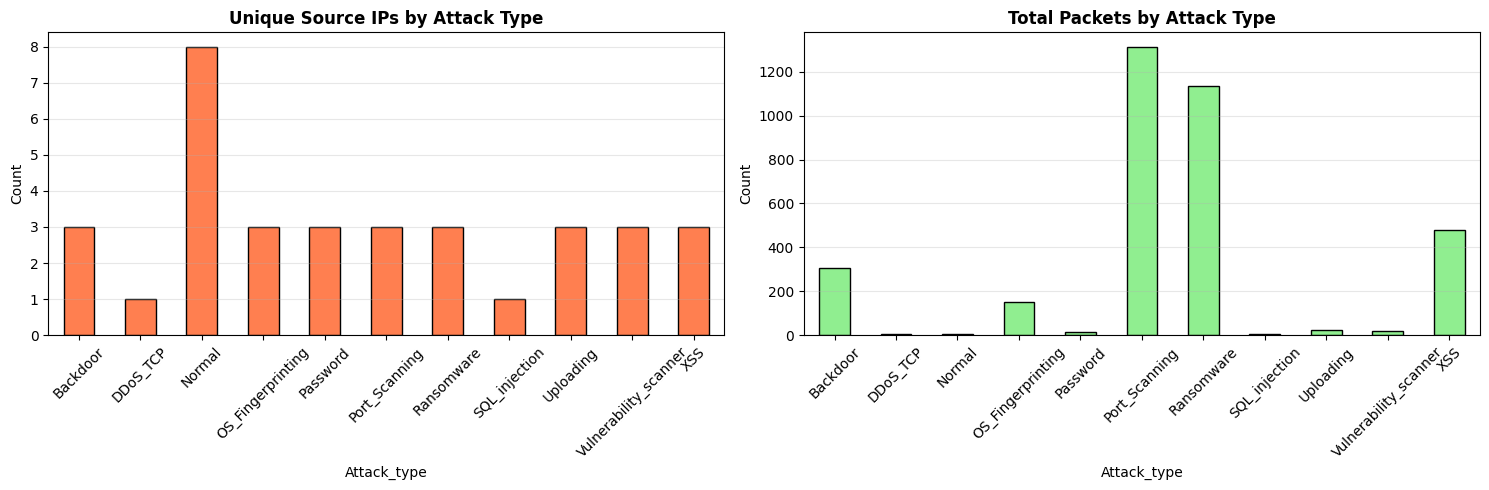


Top IPs per Attack Type:

Ransomware:
  0: 957 packets
  192.168.0.128: 120 packets
  0.0.0.0: 60 packets

Password:
  0: 13 packets
  192.168.0.128: 2 packets
  0.0.0.0: 1 packets

Port_Scanning:
  0: 1245 packets
  0.0.0.0: 35 packets
  192.168.0.128: 34 packets

XSS:
  0: 358 packets
  192.168.0.128: 80 packets
  0.0.0.0: 39 packets

Backdoor:
  0: 249 packets
  192.168.0.128: 38 packets
  0.0.0.0: 18 packets

DDoS_TCP:
  0: 4 packets

Vulnerability_scanner:
  0: 14 packets
  192.168.0.128: 2 packets
  0.0.0.0: 1 packets

SQL_injection:
  0: 4 packets

OS_Fingerprinting:
  0: 132 packets
  192.168.0.128: 12 packets
  0.0.0.0: 6 packets

Uploading:
  0: 20 packets
  192.168.0.128: 2 packets
  0.0.0.0: 1 packets

Normal:
  192.168.0.1: 326 packets
  192.168.0.128: 323 packets
  0: 14 packets


In [18]:
# 7. Source IP Analysis
print("=== Source IP Analysis ===\n")

# Group by attack type and get unique IPs and packet counts
ip_analysis = df_combined.groupby('Attack_type').agg({
    'ip.src_host': 'nunique',
    'frame.time': 'count'
}).rename(columns={'ip.src_host': 'Unique_IPs', 'frame.time': 'Total_Packets'})

print("IP and Packet Statistics by Attack Type:")
print(ip_analysis)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Unique IPs per attack type
ip_analysis['Unique_IPs'].plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Unique Source IPs by Attack Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Packets per attack type
ip_analysis['Total_Packets'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Total Packets by Attack Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show top IPs per attack type
print("\nTop IPs per Attack Type:")
for attack_type in df_combined['Attack_type'].unique():
    attack_ips = df_combined[df_combined['Attack_type'] == attack_type]['ip.src_host'].value_counts().head(3)
    print(f"\n{attack_type}:")
    for ip, count in attack_ips.items():
        print(f"  {ip}: {count} packets")

In [19]:
# 8. Data Summary & Insights
print("=== Data Summary & Key Insights ===\n")

print(f"Total Records: {len(df_combined):,}")
print(f"Total Unique IPs: {df_combined['ip.src_host'].nunique()}")
print(f"Time Range: {df_combined['frame.time'].min()} to {df_combined['frame.time'].max()}")
print(f"Total Features: {len(feature_cols)}")
print(f"\nAttack Type Distribution:")
for attack, count in df_combined['Attack_type'].value_counts().items():
    pct = (count / len(df_combined)) * 100
    print(f"  • {attack:30s}: {count:6,} ({pct:5.1f}%)")

# Data quality metrics
print(f"\nData Quality:")
print(f"  • Missing values in frame.time: {df_combined['frame.time'].isna().sum()}")
print(f"  • Missing values in ip.src_host: {df_combined['ip.src_host'].isna().sum()}")
print(f"  • Duplicate rows: {df_combined.duplicated().sum()}")

# Feature statistics
print(f"\nFeature Statistics (scaled):")
print(f"  • Mean: {df_scaled[feature_cols].mean().mean():.4f}")
print(f"  • Std: {df_scaled[feature_cols].std().mean():.4f}")
print(f"  • Min: {df_scaled[feature_cols].min().min():.4f}")
print(f"  • Max: {df_scaled[feature_cols].max().max():.4f}")

=== Data Summary & Key Insights ===

Total Records: 4,115
Total Unique IPs: 8
Time Range: 2021-01-01 00:00:06.541715 to 2022-01-01 00:48:15.953530
Total Features: 41

Attack Type Distribution:
  • Port_Scanning                 :  1,314 ( 31.9%)
  • Ransomware                    :  1,137 ( 27.6%)
  • Normal                        :    668 ( 16.2%)
  • XSS                           :    477 ( 11.6%)
  • Backdoor                      :    305 (  7.4%)
  • OS_Fingerprinting             :    150 (  3.6%)
  • Uploading                     :     23 (  0.6%)
  • Vulnerability_scanner         :     17 (  0.4%)
  • Password                      :     16 (  0.4%)
  • DDoS_TCP                      :      4 (  0.1%)
  • SQL_injection                 :      4 (  0.1%)

Data Quality:
  • Missing values in frame.time: 661
  • Missing values in ip.src_host: 0
  • Duplicate rows: 4

Feature Statistics (scaled):
  • Mean: -0.0000
  • Std: 0.3415
  • Min: -2.5813
  • Max: 45.3486


## 4. Create Time Series Sequences

In [27]:
# Create sequences from time series data (flattened for XGBoost)
print("Creating time series sequences for XGBoost...\n")

SEQ_LEN = 10  # Sequence length

def create_sequences_xgboost(df, feature_cols, seq_len=10):
    """Creates flattened sequences for XGBoost"""
    X_seq, y_seq = [], []
    
    for ip, group in df.groupby('ip.src_host'):
        group = group.sort_values('frame.time')
        
        X = group[feature_cols].values
        y = group['Attack_type'].values
        
        # Create sequences and flatten them
        for i in range(len(group) - seq_len):
            # Flatten sequence: shape (seq_len, n_features) -> (seq_len * n_features,)
            X_flat = X[i:i+seq_len].flatten()
            X_seq.append(X_flat)
            y_seq.append(y[i+seq_len])
    
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences_xgboost(df_scaled, feature_cols, seq_len=SEQ_LEN)

print(f"✓ Sequences created (flattened for XGBoost)")
print(f"  X shape: {X_seq.shape} (samples, flattened_features)")
print(f"  y shape: {y_seq.shape} (samples,)")
print(f"\nAttack type distribution:")
for attack_type, count in pd.Series(y_seq).value_counts().items():
    print(f"  • {attack_type}: {count} sequences")

Creating time series sequences for XGBoost...

✓ Sequences created (flattened for XGBoost)
  X shape: (4071, 410) (samples, flattened_features)
  y shape: (4071,) (samples,)

Attack type distribution:
  • Port_Scanning: 1313 sequences
  • Ransomware: 1109 sequences
  • Normal: 654 sequences
  • XSS: 477 sequences
  • Backdoor: 305 sequences
  • OS_Fingerprinting: 150 sequences
  • Uploading: 23 sequences
  • Vulnerability_scanner: 17 sequences
  • Password: 15 sequences
  • DDoS_TCP: 4 sequences
  • SQL_injection: 4 sequences


## 5. Prepare Data for XGBoost

In [ ]:
from sklearn.preprocessing import LabelEncoder

print("Encoding labels for XGBoost...\n")

# Encode attack types
le = LabelEncoder()
y_encoded = le.fit_transform(y_seq)
num_classes = len(le.classes_)

print(f"Number of attack classes: {num_classes}")
print(f"\nClass mapping:")
for idx, label in enumerate(le.classes_):
    print(f"  {idx}: {label}")

print(f"\nLabel distribution:")
for idx, label in enumerate(le.classes_):
    count = (y_encoded == idx).sum()
    print(f"  {label}: {count} samples")

Encoding labels...
Number of attack classes: 11

Class mapping:
  0: Backdoor
  1: DDoS_TCP
  2: Normal
  3: OS_Fingerprinting
  4: Password
  5: Port_Scanning
  6: Ransomware
  7: SQL_injection
  8: Uploading
  9: Vulnerability_scanner
  10: XSS

Categorical labels shape: (4071, 11)


In [ ]:
# Split data into train and test sets (80-20 split)
print("Splitting data into train and test sets...\n")

split_ratio = 0.8
split_index = int(len(X_seq) * split_ratio)

X_train = X_seq[:split_index]
X_test = X_seq[split_index:]
y_train = y_encoded[:split_index]
y_test = y_encoded[split_index:]

print(f"Train set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set:  X_test {X_test.shape}, y_test {y_test.shape}")
print(f"\nTrain-Test Split Ratio: {len(X_train)} / {len(X_test)}")

Splitting data into train and test sets...
Train set: X_train (3256, 10, 41), y_train (3256, 11)
Test set:  X_test (815, 10, 41), y_test (815, 11)


## 6. Build and Train XGBoost Model

In [ ]:
# Build and train XGBoost model
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Building and training XGBoost model...\n")

# Create XGBoost classifier
model = xgb.XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=num_classes,
    max_depth=8,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    eval_metric='mlogloss'
)

print("Model Hyperparameters:")
print(f"  • n_estimators: {model.n_estimators}")
print(f"  • max_depth: {model.max_depth}")
print(f"  • learning_rate: {model.learning_rate}")
print(f"  • subsample: {model.subsample}")
print(f"  • colsample_bytree: {model.colsample_bytree}")

print("\n" + "="*60)
print("Training XGBoost model...")
print("="*60)

# Train with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=10,
    verbose=False
)

print("\n✓ Model training completed")
print(f"Best iteration: {model.best_iteration}")

Building LSTM model...

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        27,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,971 (160.04 KB)

 Trainable params: 40,971 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Feature Importance Analysis
print("Analyzing feature importance...\n")

# Get feature importance
importance = model.feature_importances_
feature_names = [f"feature_{i}" for i in range(len(importance))]

# Sort by importance
indices = np.argsort(importance)[::-1]

print("Top 20 Most Important Features:")
for i in range(min(20, len(indices))):
    print(f"  {i+1:2d}. Feature {indices[i]:4d}: {importance[indices[i]]:.6f}")

# Plot top 20 important features
fig, ax = plt.subplots(figsize=(12, 6))
top_indices = indices[:20]
ax.barh(range(len(top_indices)), importance[top_indices], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top_indices)))
ax.set_yticklabels([f"Feature {i}" for i in top_indices])
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Setting up callbacks...
✓ Callbacks configured


In [ ]:
# Model Predictions
print("Making predictions on test set...\n")

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction probabilities shape: {y_pred_proba.shape}")
print("\n✓ Predictions completed")

Training LSTM model...

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.4542 - loss: 1.6613 - val_accuracy: 0.8589 - val_loss: 1.8569 - learning_rate: 0.0010
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5448 - loss: 1.2003 - val_accuracy: 0.8613 - val_loss: 1.2897 - learning_rate: 0.0010
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5660 - loss: 1.1012 - val_accuracy: 0.8577 - val_loss: 0.8602 - learning_rate: 0.0010
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6001 - loss: 1.0188 - val_accuracy: 0.8564 - val_loss: 0.6983 - learning_rate: 0.0010
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6143 - loss: 1.0062 - val_accuracy: 0.8368 - val_loss: 0.6224 - learning_rate: 0.0010
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6195 - loss: 0.9799 - val_accuracy: 0.8368 - val_loss: 0.5245 - learning_rate: 0.0010
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6265

## 7. Model Evaluation

In [ ]:
print("=== XGBoost Model Evaluation ===\n")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Evaluating model...

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Test Accuracy: 0.8368

Classification Report:


ValueError: Number of classes, 9, does not match size of target_names, 11. Try specifying the labels parameter

In [ ]:
# Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - LSTM Attack Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. Plot Model Learning Curve

In [ ]:
# Plot XGBoost evaluation metrics
print("Plotting XGBoost evaluation results...\n")

# Get evaluation results
results = model.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Get metric names
metric_names = list(results.keys())

if metric_names:
    for metric_name in metric_names:
        metrics = results[metric_name]
        
        # Plot training and validation metrics
        ax = axes[0] if metric_name == 'validation_0' else axes[1]
        
        if 'validation_0' in results:
            ax.plot(results['validation_0'][list(results['validation_0'].keys())[0]], 
                   label='Validation', color='orange', linewidth=2)
        
        ax.set_title(f'XGBoost Learning Curve', fontsize=12, fontweight='bold')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Log Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        break

# Alternative: Show training and validation accuracy
print("Training and Validation Performance:")
train_acc = accuracy_score(y_train, model.predict(X_train))
val_acc = accuracy_score(y_test, y_pred)

print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Validation Accuracy: {val_acc:.4f}")

# Plot comparison
ax = axes[1] if len(metric_names) > 0 else axes[0]
categories = ['Train', 'Validation']
accuracies = [train_acc, val_acc]
colors_bar = ['skyblue', 'coral']

ax.bar(categories, accuracies, color=colors_bar, edgecolor='black', alpha=0.7)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Train vs Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(accuracies):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Save XGBoost Model

In [ ]:
# Save model and artifacts
import pickle
import json

print("Saving XGBoost model and artifacts...\n")

# Save XGBoost model (JSON format for better portability)
model.save_model('xgboost_attack_detection_model.json')
print("✓ XGBoost model saved as 'xgboost_attack_detection_model.json'")

# Also save as pickle
with open('xgboost_attack_detection_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✓ XGBoost model saved as 'xgboost_attack_detection_model.pkl'")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ StandardScaler saved as 'scaler.pkl'")

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✓ Label encoder saved as 'label_encoder.pkl'")

# Save model information
model_info = {
    'model_type': 'XGBoost',
    'num_classes': num_classes,
    'class_names': le.classes_.tolist(),
    'n_features': X_train.shape[1],
    'sequence_length': SEQ_LEN,
    'test_accuracy': float(accuracy_score(y_test, y_pred)),
    'train_accuracy': float(accuracy_score(y_train, model.predict(X_train)))
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print("✓ Model info saved as 'model_info.json'")

print("\n" + "="*60)
print("✓ All artifacts saved successfully!")
print("="*60)
print("\nModel Summary:")
print(f"  • Algorithm: XGBoost")
print(f"  • Classes: {num_classes}")
print(f"  • Features (flattened): {X_train.shape[1]}")
print(f"  • Train Accuracy: {accuracy_score(y_train, model.predict(X_train)):.4f}")
print(f"  • Test Accuracy: {accuracy:.4f}")